In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load image model class info
with open('data/processed/data_splits.pkl', 'rb') as f:
    image_data = pickle.load(f)

# Load tabular info
with open('data/processed/tabular_info.pkl', 'rb') as f:
    tabular_info = pickle.load(f)

# Load scaler and label encoder
scaler = joblib.load('models/tabular_scaler.pkl')
label_encoder = joblib.load('models/label_encoder.pkl')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Everything loaded successfully!")
print(f"Device: {device}")
print(f"Image classes: {len(image_data['classes'])}")
print(f"Tabular classes: {tabular_info['n_classes']}")
print(f"Tabular features: {tabular_info['feature_names']}")

Everything loaded successfully!
Device: cpu
Image classes: 15
Tabular classes: 6
Tabular features: ['soil_pH', 'nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'rainfall']


In [2]:
# Load ResNet50 architecture
resnet = models.resnet50(weights='IMAGENET1K_V1')
resnet.fc = nn.Linear(2048, len(image_data['classes']))

# Load our fine-tuned weights
resnet.load_state_dict(torch.load('models/resnet50_finetuned.pth'))
resnet = resnet.to(device)

# Remove the final classification layer to get embeddings
# We hook into the layer just before fc
embedding_model = nn.Sequential(*list(resnet.children())[:-1])
embedding_model = embedding_model.to(device)
embedding_model.eval()

# Test with a dummy input
dummy = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    test_embedding = embedding_model(dummy)
    test_embedding = test_embedding.squeeze()

print("Feature extractor ready!")
print(f"Input shape:  (1, 3, 224, 224)")
print(f"Output shape: {test_embedding.shape} — this is the image embedding vector")

Feature extractor ready!
Input shape:  (1, 3, 224, 224)
Output shape: torch.Size([2048]) — this is the image embedding vector


In [3]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class FusionDataset(Dataset):
    def __init__(self, image_paths, image_labels, tabular_features, tabular_labels, transform=None):
        self.image_paths = image_paths
        self.image_labels = image_labels
        self.tabular_features = tabular_features
        self.tabular_labels = tabular_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)

        # Get tabular features
        tab = torch.tensor(self.tabular_features[idx], dtype=torch.float32)

        # Get labels
        img_label = self.image_labels[idx]
        tab_label = self.tabular_labels[idx]

        return img, tab, img_label, tab_label

# Load tabular data
df = pd.read_csv('data/tabular_features.csv')
X_tab = scaler.transform(df.drop('disease', axis=1).values)
y_tab = label_encoder.transform(df['disease'].values)

# Match lengths — use min of both datasets
n = min(len(image_data['train_paths']), len(X_tab))
print(f"Using {n} samples for fusion dataset")

# Create fusion dataset using matched samples
fusion_dataset = FusionDataset(
    image_paths=image_data['train_paths'][:n],
    image_labels=image_data['train_labels'][:n],
    tabular_features=X_tab[:n],
    tabular_labels=y_tab[:n],
    transform=val_transform
)

fusion_loader = DataLoader(fusion_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Fusion dataset size: {len(fusion_dataset)}")
print(f"Fusion batches: {len(fusion_loader)}")

# Test one sample
img, tab, img_lbl, tab_lbl = fusion_dataset[0]
print(f"\nSample shapes:")
print(f"  Image tensor: {img.shape}")
print(f"  Tabular tensor: {tab.shape}")
print(f"  Image label: {img_lbl} → {image_data['classes'][img_lbl]}")
print(f"  Tabular label: {tab_lbl} → {label_encoder.classes_[tab_lbl]}")

Using 5000 samples for fusion dataset
Fusion dataset size: 5000
Fusion batches: 157

Sample shapes:
  Image tensor: torch.Size([3, 224, 224])
  Tabular tensor: torch.Size([7])
  Image label: 9 → Tomato_Septoria_leaf_spot
  Tabular label: 2 → Healthy


In [4]:
print("Extracting image embeddings... (this takes a few minutes)")

all_embeddings = []
all_image_labels = []
all_tabular_features = []
all_tabular_labels = []

embedding_model.eval()
with torch.no_grad():
    for batch_idx, (images, tab_features, img_labels, tab_labels) in enumerate(fusion_loader):
        images = images.to(device)
        
        # Get image embeddings
        embeddings = embedding_model(images)
        embeddings = embeddings.squeeze(-1).squeeze(-1)  # (batch, 2048)
        
        all_embeddings.append(embeddings.cpu().numpy())
        all_image_labels.extend(img_labels.numpy())
        all_tabular_features.append(tab_features.numpy())
        all_tabular_labels.extend(tab_labels.numpy())
        
        if (batch_idx + 1) % 25 == 0:
            print(f"  Processed {(batch_idx+1)*32}/{len(fusion_dataset)} images")

# Stack everything
all_embeddings = np.vstack(all_embeddings)
all_tabular_features = np.vstack(all_tabular_features)
all_image_labels = np.array(all_image_labels)
all_tabular_labels = np.array(all_tabular_labels)

print(f"\nDone!")
print(f"Image embeddings shape: {all_embeddings.shape}")
print(f"Tabular features shape: {all_tabular_features.shape}")

# Save embeddings
np.save('data/processed/image_embeddings.npy', all_embeddings)
np.save('data/processed/image_labels.npy', all_image_labels)
np.save('data/processed/tabular_features_matched.npy', all_tabular_features)
np.save('data/processed/tabular_labels_matched.npy', all_tabular_labels)
print("Embeddings saved!")

Extracting image embeddings... (this takes a few minutes)
  Processed 800/5000 images
  Processed 1600/5000 images
  Processed 2400/5000 images
  Processed 3200/5000 images
  Processed 4000/5000 images
  Processed 4800/5000 images

Done!
Image embeddings shape: (5000, 2048)
Tabular features shape: (5000, 7)
Embeddings saved!


In [5]:
# Concatenate image embeddings + tabular features
X_fused = np.concatenate([all_embeddings, all_tabular_features], axis=1)
print(f"Fused feature shape: {X_fused.shape}  → (samples, 2048 + 7)")

# We'll use image labels as the target (15 disease classes)
y_fused = all_image_labels

# Split into train/val/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_fused, y_fused, test_size=0.2, random_state=42, stratify=y_fused
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f"\nFusion split sizes:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# Build fusion MLP
class FusionMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.network(x)

fusion_model = FusionMLP(input_dim=2055, num_classes=15).to(device)

total_params = sum(p.numel() for p in fusion_model.parameters())
print(f"\nFusion MLP parameters: {total_params:,}")
print("Model architecture:")
print(fusion_model)

Fused feature shape: (5000, 2055)  → (samples, 2048 + 7)

Fusion split sizes:
  Train: (3400, 2055)
  Val:   (600, 2055)
  Test:  (1000, 2055)

Fusion MLP parameters: 1,187,855
Model architecture:
FusionMLP(
  (network): Sequential(
    (0): Linear(in_features=2055, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=15, bias=True)
  )
)


In [6]:
from torch.utils.data import TensorDataset

# Create data loaders from tensors
train_loader_f = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader_f   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=32, shuffle=False)
test_loader_f  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=32, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fusion_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_accs, val_accs = [], []
train_losses, val_losses = [], []
best_val_acc = 0.0
num_epochs = 20

print("Training fusion MLP...\n")

for epoch in range(num_epochs):
    # Train
    fusion_model.train()
    correct, total, running_loss = 0, 0, 0.0
    for X_batch, y_batch in train_loader_f:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = fusion_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()
    train_loss = running_loss / len(train_loader_f)
    train_acc = 100. * correct / total

    # Validate
    fusion_model.eval()
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_f:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = fusion_model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()
    val_loss = running_loss / len(val_loader_f)
    val_acc = 100. * correct / total

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(fusion_model.state_dict(), 'models/fusion_mlp_best.pth')

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.1f}% | "
              f"Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.1f}%")

print(f"\nBest val accuracy: {best_val_acc:.1f}%")

Training fusion MLP...

Epoch  5/20 | Train Loss: 0.015 | Train Acc: 99.5% | Val Loss: 0.002 | Val Acc: 100.0%
Epoch 10/20 | Train Loss: 0.002 | Train Acc: 99.9% | Val Loss: 0.007 | Val Acc: 99.5%
Epoch 15/20 | Train Loss: 0.001 | Train Acc: 100.0% | Val Loss: 0.001 | Val Acc: 100.0%
Epoch 20/20 | Train Loss: 0.000 | Train Acc: 100.0% | Val Loss: 0.001 | Val Acc: 99.8%

Best val accuracy: 100.0%


Fusion Model Test Accuracy: 99.80%

Comparison:
  Image only  (ResNet50):  99.52%
  Tabular only (XGBoost):  99.50%
  Fusion (image + tabular): 99.80%


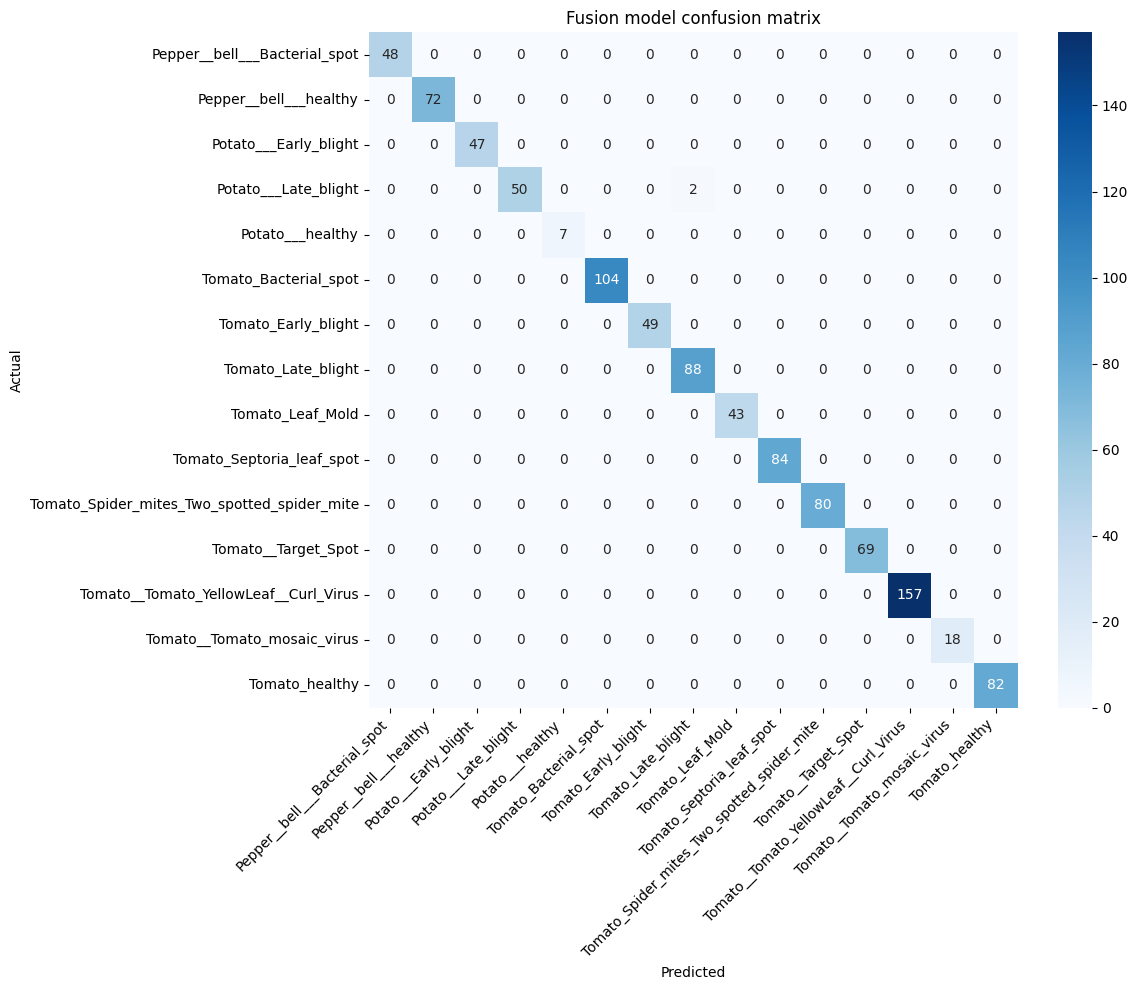


All models saved and ready!
  models/fusion_mlp_best.pth
  models/resnet50_finetuned.pth
  models/xgboost_tabular.json


In [7]:
# Load best fusion model
fusion_model.load_state_dict(torch.load('models/fusion_mlp_best.pth'))
fusion_model.eval()

# Evaluate on test set
correct, total = 0, 0
all_preds, all_true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader_f:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = fusion_model(X_batch)
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())

test_acc = 100. * correct / total
print(f"Fusion Model Test Accuracy: {test_acc:.2f}%")
print(f"\nComparison:")
print(f"  Image only  (ResNet50):  99.52%")
print(f"  Tabular only (XGBoost):  99.50%")
print(f"  Fusion (image + tabular): {test_acc:.2f}%")

# Plot confusion matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=image_data['classes'],
            yticklabels=image_data['classes'])
plt.title('Fusion model confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/fusion_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the fusion model info
fusion_info = {
    'input_dim': 2055,
    'num_classes': 15,
    'image_classes': image_data['classes'],
    'class_to_idx': image_data['class_to_idx']
}
with open('data/processed/fusion_info.pkl', 'wb') as f:
    pickle.dump(fusion_info, f)

print("\nAll models saved and ready!")
print("  models/fusion_mlp_best.pth")
print("  models/resnet50_finetuned.pth")
print("  models/xgboost_tabular.json")